In [345]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from collections import namedtuple
import numpy as np
import jax.numpy as jnp
import jax.scipy as jscipy
from jax.scipy.optimize import minimize as jminimize
import jax
import optax
import jaxopt
#from statsmodels.api import Poisson
import polars as pl
from sklearn.datasets import fetch_openml
from sklearn.linear_model import TweedieRegressor
from actuarial_python_tooling.plots import _prepare_simple_lift_plot_data, plot_simple_lift_plot, plot_obs_pred_by_feature_value, _prepare_obs_pred_by_feature_value
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from functools import partial
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import PoissonRegressor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [347]:
from actuarial_python_tooling.models.poisson import (
    poisson_neg_log_loss,
    solve_via_adam,
    solve_via_jaxopt,
    solve_via_jaxopt_scipy,
    solve_via_optax,
    poisson_neg_log_loss_no_jit,
)

In [109]:
from sklearn.datasets import fetch_openml


def load_mtpl2(n_samples=None):
    """Fetch the French Motor Third-Party Liability Claims dataset.

    Parameters
    ----------
    n_samples: int, default=None
      number of samples to select (for faster run time). Full dataset has
      678013 samples.
    """
    # freMTPL2freq dataset from https://www.openml.org/d/41214
    df_freq = fetch_openml(data_id=41214, as_frame=True).data
    df_freq["IDpol"] = df_freq["IDpol"].astype(int)
    df_freq.set_index("IDpol", inplace=True)
    print(df_freq["ClaimNb"].value_counts())

    # freMTPL2sev dataset from https://www.openml.org/d/41215
    df_sev = fetch_openml(data_id=41215, as_frame=True).data

    # sum ClaimAmount over identical IDs
    df_sev = df_sev.groupby("IDpol").sum()

    df = df_freq.join(df_sev, how="left")
    df["ClaimAmount"] = df["ClaimAmount"].fillna(0)

    # unquote string fields
    for column_name in df.columns[df.dtypes.values == object]:
        df[column_name] = df[column_name].str.strip("'")
    return df.iloc[:n_samples]

# Scipy poisson

In [110]:
# https://gist.github.com/ahwillia/40cdbe3b2f2df1806358dd1e6de0743a
n = 1000  # number of datapoints
p = 5  # number of features

# create data
X = 0.3 * np.random.randn(n, p)
true_b = np.random.randn(p)
y = np.random.poisson(np.exp(np.dot(X, true_b)))
yg = np.random.gamma(np.exp(np.dot(X, true_b)))

# LightGBM poisson loss: loss = exp(f) - label * f
# https://github.com/microsoft/LightGBM/blob/master/src/objective/regression_objective.hpp
# SCIKIT LEARN: https://github.com/scikit-learn/scikit-learn/blob/70fdc843a4b8182d97a3508c1a426acc5e87e980/sklearn/_loss/loss.py
#         loss(x_i) = y_true_i * log(y_true_i/exp(raw_prediction_i))
#                    - y_true_i + exp(raw_prediction_i)
# IN JAX: return -1 * jnp.sum(model.y * jnp.log(μ) - μ - jnp.log(jax_factorial(y)))
# IN JAX: return +1 * jnp.sum(-1 * model.y * jnp.log(μ) + μ + jnp.log(jax_factorial(y)))
# der letzte Teil ist unten nicht mit dabei und kann vermutlich entfernt werden?
# loss function and gradient
def f(b):
    Xb = np.dot(X, b)
    exp_Xb = np.exp(Xb)
    loss = exp_Xb.sum() - np.dot(y, Xb)
    grad = np.dot(X.T, exp_Xb - y)
    return loss, grad


# hessian
def hess(b):
    return np.dot(X.T, np.exp(np.dot(X, b))[:, None] * X)


# optimize
result = minimize(f, np.zeros(p), jac=True, hess=hess, method="newton-cg")

print("True regression coeffs: {}".format(true_b))
print("Estimated regression coeffs: {}".format(result.x))

True regression coeffs: [ 0.13142743  0.46229352 -0.26430148 -0.46267467  0.85274685]
Estimated regression coeffs: [ 0.14592897  0.46176257 -0.2212053  -0.57309683  0.82942686]


In [111]:
def load_mtpl2(n_samples=None):
    """Fetch the French Motor Third-Party Liability Claims dataset.

    Parameters
    ----------
    n_samples: int, default=None
      number of samples to select (for faster run time). Full dataset has
      678013 samples.
    """
    # freMTPL2freq dataset from https://www.openml.org/d/41214
    df_freq = fetch_openml(data_id=41214, as_frame=True).data
    df_freq["IDpol"] = df_freq["IDpol"].astype(int)
    df_freq.set_index("IDpol", inplace=True)
    print(df_freq["ClaimNb"].value_counts())

    # freMTPL2sev dataset from https://www.openml.org/d/41215
    df_sev = fetch_openml(data_id=41215, as_frame=True).data

    # sum ClaimAmount over identical IDs
    df_sev = df_sev.groupby("IDpol").sum()

    df = df_freq.join(df_sev, how="left")
    df["ClaimAmount"] = df["ClaimAmount"].fillna(0)

    # unquote string fields
    for column_name in df.columns[df.dtypes.values == object]:
        df[column_name] = df[column_name].str.strip("'")
    return df.iloc[:n_samples]

In [112]:
df = load_mtpl2()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64


In [113]:
claim_data = pl.from_pandas(df[df["ClaimAmount"] > 0])
claim_data_pd = df[df["ClaimAmount"] > 0]
sev_data = pl.from_pandas(df)
sev_data_pd = df

In [114]:
claim_data.head()

ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
i64,f64,cat,i64,i64,i64,i64,cat,str,i64,cat,f64
1,0.75,"""F""",7,1,61,50,"""B12""","""Regular""",27000,"""R11""",303.0
1,0.14,"""B""",12,5,50,60,"""B12""","""Diesel""",56,"""R25""",1981.84
1,0.14,"""E""",4,0,36,85,"""B12""","""Regular""",4792,"""R11""",1456.55
2,0.62,"""F""",10,0,51,100,"""B12""","""Regular""",27000,"""R11""",10834.0
1,0.31,"""A""",5,0,45,50,"""B12""","""Regular""",12,"""R73""",3986.67


In [115]:
tweedie = TweedieRegressor(power = 1.9)

In [116]:
tweedie = tweedie.fit(
    claim_data_pd[["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]],
    claim_data_pd["ClaimAmount"].to_numpy(),
)

/Users/jan-hendrikzab/envs/actuarial-priv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


In [117]:
predictions = tweedie.predict(claim_data_pd[["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]])

In [118]:
claim_data = claim_data.with_columns(pl.from_numpy(predictions)["column_0"].alias("PREDICTION"))

In [119]:
plot_data = _prepare_simple_lift_plot_data(
    claim_data,
    prediction_col="PREDICTION",
    target_col="ClaimAmount",
    weights_col="Exposure",
    weighted_mean=True,
)
plot_data.head()

2024-07-28 16:05:06.697 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:25 - Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PLUS_ONE']
2024-07-28 16:05:06.698 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:27 - Breaks: [1727.892826109739, 3455.785652219478, 5183.678478329217, 6911.571304438956, 8639.464130548695, 10367.356956658434, 12095.249782768173, 13823.142608877912, 15551.035434987652, 17278.92826109739]


CUT_WEIGHTS,ClaimAmount,PREDICTION,SEGMENT_NAMES,Exposure,SUMMED_WEIGHTS,NUM_OBS
cat,f64,f64,str,f64,f64,u32
"""0""",1711.761979,2401.748577,"""0: 2401.7 - 2401.7""",1726.960984,1726.960984,2391
"""1""",2197.858556,2401.748577,"""1: 2401.7 - 2401.7""",1728.56459,3455.525574,2462
"""2""",1952.751498,2401.748577,"""2: 2401.7 - 2401.7""",1728.069178,5183.594752,2306
"""3""",2250.190178,2401.748577,"""3: 2401.7 - 2401.7""",1727.943699,6911.53845,2384
"""4""",1769.86667,2401.748577,"""4: 2401.7 - 2401.7""",1727.395479,8638.93393,2342


In [120]:
%config InlineBackend.figure_formats = ['svg']

2024-07-28 16:05:06.788 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:25 - Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'PLUS_ONE']
2024-07-28 16:05:06.788 | DEBUG    | actuarial_python_tooling.plots:_prepare_simple_lift_plot_data:27 - Breaks: [1727.892826109739, 3455.785652219478, 5183.678478329217, 6911.571304438956, 8639.464130548695, 10367.356956658434, 12095.249782768173, 13823.142608877912, 15551.035434987652, 17278.92826109739]


<Axes: xlabel='Prediction segments', ylabel='Pure Premium'>

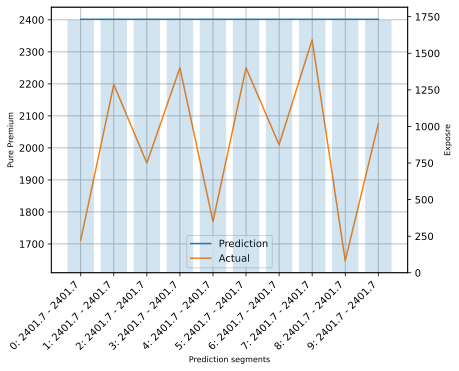

In [121]:
plot_simple_lift_plot(
    claim_data, prediction_col="PREDICTION", target_col="ClaimAmount", weights_col="Exposure", weighted_mean=True
)

In [122]:
jax.config.update("jax_enable_x64", True)

In [123]:
RegressionModel = namedtuple("RegressionModel", ["X", "y"])


def create_regression_model(X, y):
    n, k = X.shape
    # Reshape y as a n_by_1 column vector
    y = y.reshape(n, 1)
    X, y = jax.device_put((X, y))
    return RegressionModel(X=X, y=y)

In [124]:
@jax.jit
def _factorial(n):
    return jax.lax.exp(jax.lax.lgamma(n + 1.0)).astype(int)


jax_factorial = jax.vmap(_factorial)

In [125]:
@jax.jit
def gamma_logL(β, model):
    y = model.y
    μ = jnp.exp(model.X @ β)

    # loss(x_i) = log(exp(raw_prediction_i)/y_true_i)
    #                + y_true/exp(raw_prediction_i) - 1
    return jnp.sum(jnp.log(μ/y) + y /μ - 1)

In [126]:
G_gamma_logL = jax.grad(gamma_logL)
H_gamma_logL = jax.jacfwd(G_gamma_logL)

In [127]:
@jax.jit
def poisson_logL(β, model):
    y = model.y
    μ = jnp.exp(model.X @ β)
    # TODO neg log like?
    #return -1 * jnp.sum(model.y * jnp.log(μ) - μ - jnp.log(jax_factorial(y)))
    return -1 * jnp.sum(model.y * jnp.log(μ) - μ)

In [128]:
@jax.jit
def poisson_logL2(β, model):
    y = model.y
    μ = jnp.exp(model.X @ β)
    return model.y * jnp.log(μ) - μ - jnp.log(jax_factorial(y))

In [129]:
G_poisson_logL = jax.grad(poisson_logL)
H_poisson_logL = jax.jacfwd(G_poisson_logL)

In [130]:
def newton_raphson(model, β, tol=1e-3, max_iter=100, display=True):
    i = 0
    error = 100  # Initial error value

    # Print header of output
    if display:
        header = f'{"Iteration_k":<13}{"Log-likelihood":<16}{"θ":<60}'
        print(header)
        print("-" * len(header))

    # While loop runs while any value in error is greater
    # than the tolerance until max iterations are reached
    update = f"{-1:<13}{poisson_logL(β, model):<16.8}{β}"
    print(update)
    while jnp.any(error > tol) and i < max_iter:
        H, G = jnp.squeeze(H_poisson_logL(β, model)), G_poisson_logL(β, model)
        β_new = β - (jnp.dot(jnp.linalg.inv(H), G))
        error = jnp.abs(β_new - β)
        β = β_new

        if display:
            β_list = [f"{t:.3}" for t in list(β.flatten())]
            update = f"{i:<13}{poisson_logL(β, model):<16.8}{β_list}"
            print(update)

        i += 1

    print(f"Number of iterations: {i}")
    print(f"β_hat = {β.flatten()}")

    return β

In [132]:
# Take a guess at initial βs
init_β = jnp.array([0.1, 0.1, 0.1, 0.1, 0.1]).reshape(X.shape[1], 1)

# Create an object with Poisson model values
poi = create_regression_model(X, y)

# Use newton_raphson to find the MLE
β_hat = newton_raphson(poi, init_β, display=True)

Iteration_k  Log-likelihood  θ                                                           
-----------------------------------------------------------------------------------------
-1           995.37188       [[0.1]
 [0.1]
 [0.1]
 [0.1]
 [0.1]]
0            934.96379       ['0.146', '0.494', '-0.245', '-0.619', '0.874']
1            934.65525       ['0.146', '0.462', '-0.221', '-0.574', '0.83']
2            934.65521       ['0.146', '0.462', '-0.221', '-0.573', '0.829']
Number of iterations: 3
β_hat = [ 0.14592897  0.46176261 -0.22120533 -0.57309688  0.82942691]


In [134]:
true_b

array([ 0.13142743,  0.46229352, -0.26430148, -0.46267467,  0.85274685])

In [147]:
solve_via_adam(X, y, init_β=jnp.array([0.11, 0.08, 0.09, 0.1, 0.12]))

(5, 1)
Objective function:  994.3563256291745
beta [[ 0.14869964]
 [ 0.46183594]
 [-0.21832655]
 [-0.57031532]
 [ 0.830211  ]]
Objective function:  934.656369607008


In [148]:
solve_via_jaxopt(X, y, init_β=jnp.array([0.11, 0.08, 0.09, 0.1, 0.12]))

(5, 1)


OptStep(params=Array([[ 0.14592914],
       [ 0.46176234],
       [-0.22120552],
       [-0.57309697],
       [ 0.82942676]], dtype=float64), state=ScipyMinimizeInfo(fun_val=Array(934.65521281, dtype=float64, weak_type=True), success=False, status=1, iter_num=5, hess_inv=LbfgsInvHessProduct(sk=[[ 9.55529079e-02  3.55839315e-01 -2.51454024e-01 -6.24844545e-01
   6.40771560e-01]
 [-5.64770193e-02  2.81882148e-02 -5.95895173e-02 -5.54175335e-02
   7.54735350e-02]
 [-3.17293862e-03 -2.58089395e-03  6.71799143e-05  7.18854552e-03
  -6.71706480e-03]
 [ 2.57042176e-05  2.67488175e-04 -1.98052354e-04 -2.23842964e-05
  -7.72019953e-05]], yk=[[ 1.51109918e+01  3.51508084e+01 -2.13260955e+01 -6.11996416e+01
   6.11085133e+01]
 [-4.60780567e+00  2.90545056e+00 -5.36786903e+00 -5.89554769e+00
   7.62111213e+00]
 [-3.67504147e-01 -3.23447363e-01  2.99210034e-02  7.88132494e-01
  -7.20815635e-01]
 [ 4.37224781e-03  2.54676559e-02 -1.82216129e-02 -3.22226753e-03
  -5.99129633e-03]]), num_fun_eval=Arra

In [332]:
mtpl = load_mtpl2()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64


In [333]:
mtpl.head()

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
IDpol,,,,,,,,,,,,
1,1,0.10,D,5,0,55,50,B12,Regular,1217,R82,0.0
3,1,0.77,D,5,0,55,50,B12,Regular,1217,R82,0.0
5,1,0.75,B,6,2,52,50,B12,Diesel,54,R22,0.0
10,1,0.09,B,7,0,46,50,B12,Diesel,76,R72,0.0
11,1,0.84,B,7,0,46,50,B12,Diesel,76,R72,0.0


In [334]:
mtpl["ClaimNb"].head(1000).mean()
mtpl["Frequency"] = mtpl["ClaimNb"] / mtpl["Exposure"]
mtpl["AvgClaimAmount"] = mtpl["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

In [335]:
X_mtpl = mtpl.head(1000)[["VehPower", "VehAge", "DrivAge", "BonusMalus"]]
X_mtpl = X_mtpl.to_numpy()
y_mtpl = mtpl.head(1000)[["Frequency"]].to_numpy()
weights_mtpl = mtpl.head(1000)[["Exposure"]].to_numpy()
sc = OneHotEncoder(sparse_output=False)
X_mtpl = sc.fit_transform(X_mtpl)#.toarray()

In [336]:
jnp.mean(y_mtpl)

Array(10.87204683, dtype=float64)

In [337]:
base = jnp.ones(shape=(X_mtpl.shape[0], 1))
X_mtpl = jnp.append(X_mtpl, base, axis = 1)

In [338]:
X_mtpl, y_mtpl, weights_mtpl = jax.device_put((X_mtpl, y_mtpl, weights_mtpl))

In [339]:
key = jax.random.key(0)
init_beta = jax.random.normal(key, (X_mtpl.shape[1],),) / 5

In [406]:
beta_adam = solve_via_adam(X_mtpl, y_mtpl, weights_mtpl, init_β=init_beta)
predictions_adam = jnp.exp(X_mtpl @ beta_adam)

Objective function:  0.6055942424514315
beta [[ 0.12908457]
 [ 0.19239675]
 [ 0.27148621]
 [ 0.23228122]
 [ 0.39797434]
 [ 0.2234351 ]
 [ 0.1083301 ]
 [ 0.35474212]
 [ 0.13517051]
 [ 0.64375209]
 [ 1.39103241]
 [ 0.4138323 ]
 [ 0.14480615]
 [ 0.07790044]
 [ 0.26253004]
 [ 0.21823037]
 [ 0.40593955]
 [-0.1385167 ]
 [-0.27732113]
 [ 0.34857886]
 [-0.0459523 ]
 [ 0.20151504]
 [ 0.18416711]
 [ 0.33061408]
 [ 0.29855893]
 [-0.00681022]
 [ 0.03399198]
 [ 0.38640085]
 [ 0.62500587]
 [ 0.41265674]
 [ 0.35546551]
 [ 0.33766117]
 [ 0.32995544]
 [ 0.24467524]
 [ 0.16423326]
 [ 0.22436928]
 [ 0.2150097 ]
 [ 0.2509809 ]
 [ 0.17737808]
 [ 0.24319316]
 [ 0.17996729]
 [ 0.09592015]
 [ 0.28765268]
 [ 0.2338938 ]
 [ 0.30102453]
 [ 0.10255205]
 [ 0.14978664]
 [ 0.13265226]
 [ 0.10350535]
 [ 0.29500412]
 [ 0.02427187]
 [ 0.07709625]
 [ 0.02268372]
 [ 0.18671225]
 [-0.05747056]
 [ 0.35957084]
 [ 0.02617053]
 [-0.25141452]
 [ 0.06988024]
 [ 0.3186818 ]
 [ 0.02439519]
 [ 0.00563505]
 [-0.10218042]
 [ 0.33217

In [384]:
beta_jaxopt = solve_via_jaxopt(X_mtpl, y_mtpl, init_β=init_beta)
predictions_jaxopt = jnp.exp(X_mtpl @ beta_jaxopt)

TypeError: solve_via_jaxopt() missing 1 required positional argument: 'weights'

In [398]:
beta_jaxopt_scipy = solve_via_jaxopt_scipy(X_mtpl, y_mtpl, weights_mtpl, init_beta).params.flatten()
predictions_jaxopt_scipy = jnp.exp(X_mtpl @ beta_jaxopt_scipy)

Array([-0.10409693, -0.04286083,  0.08111823,  0.01864627,  0.25184425,
        0.00218526, -0.16640196,  0.17944381,  0.06967687,  0.18859684,
        0.53931108,  0.36952037,  0.14778321,  0.00554737,  0.25531952,
        0.23269017,  0.36634199, -0.23063539, -0.39339688,  0.37338904,
        0.00567007,  0.17936759, -0.02058573,  0.11645741,  0.22811187,
       -0.21314911, -0.14168908,  0.27700772,  0.53613916,  0.29650296,
        0.23205338,  0.17805315,  0.25626828,  0.07261309,  0.00224542,
        0.02138736,  0.09332537,  0.1079909 ,  0.04241768,  0.096149  ,
        0.04311114, -0.04442864,  0.12653601,  0.0664021 ,  0.06927978,
       -0.07967004, -0.02924628, -0.04917937, -0.10507617,  0.13694691,
       -0.16958187, -0.09847776, -0.15528284, -0.00124515, -0.266587  ,
        0.25256735, -0.12045344, -0.21688961, -0.12591934,  0.17696713,
       -0.15490481, -0.25253572, -0.27667627,  0.17171776,  0.69460748,
       -0.40672857, -0.21247402, -0.09380159, -0.29220555,  0.01

In [368]:
jnp.mean(predictions_jaxopt_scipy)

Array(2.66594349, dtype=float64)

In [359]:
beta_optax  = solve_via_optax(X_mtpl, y_mtpl, weights_mtpl, init_β=init_beta)
beta_optax

Traced<ShapedArray(float64[1000])>with<DynamicJaxprTrace(level=4/0)>
Traced<ShapedArray(float64[1000])>with<DynamicJaxprTrace(level=4/0)>
value (objective function) 0.603261747004155
Traced<ShapedArray(float64[1000])>with<DynamicJaxprTrace(level=5/0)>
Traced<ShapedArray(float64[1000])>with<DynamicJaxprTrace(level=5/0)>
value (objective function) -13.656383690391184
value (objective function) -13.676129458514115
value (objective function) -13.936001659179164
value (objective function) -14.280500494610795
value (objective function) -14.514931276794838
value (objective function) -14.667551109564876
value (objective function) -14.770437418910133
value (objective function) -14.842111639581606
value (objective function) -14.89336246333038


Array([ 2.78622042e-01,  2.86055631e-01,  3.01431812e-01,  1.96351878e-01,
        1.78321422e-01,  3.02531958e-01,  3.18681724e-01,  7.61677700e-02,
       -1.15032277e-01,  1.24991414e-01,  1.68678695e-01,  3.41839930e-01,
        2.65937875e-01,  2.27486830e-01,  2.75188350e-01,  3.02117198e-01,
        3.20319759e-01,  2.52092658e-01,  9.39046992e-02,  1.05425275e-01,
       -4.48126026e-02,  2.71436259e-01,  2.01407184e-01,  2.30950991e-01,
       -1.11680894e-01,  9.93140981e-02,  1.32967566e-03,  2.92807265e-02,
        1.78487718e-01,  3.34351162e-02,  2.06370136e-01, -1.11328028e-01,
       -2.04612440e-02,  6.57534260e-02,  6.74961424e-02,  2.06235840e-01,
        1.02341863e-01, -5.28664263e-02, -5.89909069e-02,  1.01798725e-01,
        1.07718485e-01, -1.93402417e-02,  1.51612720e-01, -9.12605751e-02,
       -2.94763609e-03, -3.23017275e-03,  1.16819877e-01,  1.32733858e-02,
        1.65429803e-01, -1.29785212e-01, -6.46637649e-02,  6.38160489e-02,
       -1.56839009e-02,  

In [360]:
predictions_optax = jnp.exp(X_mtpl @ beta_optax)
predictions_optax

Array([11.66416284, 11.66416284, 10.32393335, 11.89647062, 11.89647062,
        9.88637771,  9.88637771,  9.82741819,  9.82741819, 10.38208424,
       10.38208424, 11.33664755, 11.04457658, 11.91551765,  9.92775756,
        9.7326462 ,  7.90905625,  7.90905625, 10.56497428, 10.56497428,
       10.56497428,  8.78940046,  8.78940046,  7.92640335, 12.48119591,
       12.48119591, 12.48119591, 11.59251758, 11.59251758, 11.59251758,
       10.35436522,  7.52281919, 10.57937691, 10.57937691, 12.58106251,
       12.58106251,  9.15216598,  9.15216598, 10.74393488, 10.74393488,
        9.82337752,  9.82337752, 10.97007244, 10.97007244, 13.35012636,
       13.35012636, 11.39804381, 11.39804381,  9.61428733, 10.48027827,
       10.48027827, 11.73260597, 11.73260597, 11.73260597,  9.73138716,
        9.73138716, 11.54087953, 11.54087953,  7.93564364,  7.93564364,
        7.93564364, 11.15304154,  9.05906832, 10.19613259, 11.30234298,
       10.93922392, 11.80115061, 12.9741743 , 11.26874986, 11.26

In [343]:
jnp.mean(predictions_optax)

Array(10.88114562, dtype=float64)

In [400]:
data = pl.from_pandas(mtpl).head(1000)
data = data.with_columns(pl.Series("PREDICTION", np.array(predictions_jaxopt_scipy)))

In [401]:
data.filter(pl.col("DrivAge") == 22).select("PREDICTION", "Frequency", "Exposure")

PREDICTION,Frequency,Exposure
f64,f64,f64
2.377869,1.492537,0.67
2.147173,1.190476,0.84
2.404419,4.761905,0.21
2.404419,2.325581,0.43
2.404419,5.555556,0.18
…,…,…
2.557234,3.333333,0.3
2.073783,1.923077,0.52
2.073783,5.263158,0.19


In [402]:
data.filter(pl.col("DrivAge") == 22).select("PREDICTION", "Frequency", "Exposure").mean()

PREDICTION,Frequency,Exposure
f64,f64,f64
2.289285,3.961346,0.41


In [403]:
_prepare_obs_pred_by_feature_value(data, "DrivAge", "PREDICTION", "Frequency", "Exposure", weighted_mean=True)

DrivAge,Frequency,PREDICTION,Exposure,ORIGINAL_PREDICTION,ORIGINAL_EXPOSURE,NUM_OBS
i64,f64,f64,f64,f64,f64,u32
22,2.439024,2.262678,4.92,2.289285,4.92,12
23,2.525253,2.450006,5.94,2.441556,5.94,13
24,2.63915,2.643373,7.578197,2.978773,7.578197,18
25,1.893287,1.833652,5.81,1.900259,5.81,11
26,1.823282,1.749564,7.13,1.768031,7.13,13
…,…,…,…,…,…,…
75,2.739339,2.727582,3.285464,2.748106,3.285464,9
76,2.083333,2.060141,2.4,2.063402,2.4,5
77,2.666667,2.663336,0.75,2.663336,0.75,2


<Axes: xlabel='Values of: DrivAge', ylabel='Pure Premium'>

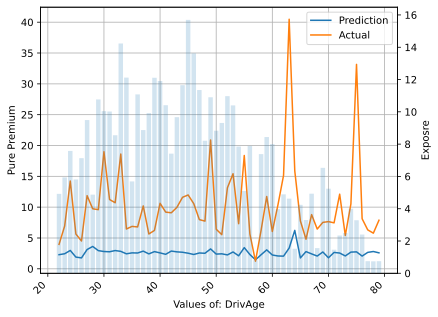

In [407]:
plot_obs_pred_by_feature_value(data, "DrivAge", "PREDICTION", "Frequency", "Exposure", weighted_mean=False)

<Axes: xlabel='Values of: DrivAge', ylabel='Pure Premium'>

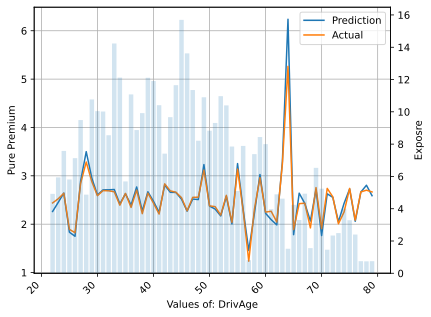

In [408]:
plot_obs_pred_by_feature_value(data, "DrivAge", "PREDICTION", "Frequency", "Exposure", weighted_mean=True)

In [397]:
data.select("ClaimNb", "Frequency", "PREDICTION").mean()

ClaimNb,Frequency,PREDICTION
f64,f64,f64
1.042,10.872047,2.665943


In [326]:
glm_freq = PoissonRegressor(alpha=1e-4, solver="newton-cholesky")
glm_freq.fit(X_mtpl, y_mtpl, sample_weight=mtpl["Exposure"].head(1000).to_numpy())
predictions_scikit = glm_freq.predict(X_mtpl)
predictions_scikit

/Users/jan-hendrikzab/envs/actuarial-priv/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([ 3.39316275,  3.39316275,  1.8712676 ,  2.85596564,  2.85596564,
        2.18429624,  2.18429624,  2.78517311,  2.78517311,  2.70907559,
        2.70907559,  2.5297617 ,  2.29376611,  2.9946207 ,  1.73481233,
        2.92817628,  2.02550414,  2.02550414,  2.623457  ,  2.623457  ,
        2.623457  ,  2.2020673 ,  2.2020673 ,  3.16612684,  2.67579045,
        2.67579045,  2.67579045,  3.25399364,  3.25399364,  3.25399364,
        2.23446249,  1.24341834,  2.63536723,  2.63536723,  2.70911586,
        2.70911586,  2.6183515 ,  2.6183515 ,  3.07995413,  3.07995413,
        2.74771076,  2.74771076,  2.4221242 ,  2.4221242 ,  2.62947482,
        2.62947482,  2.42028572,  2.42028572,  2.11727411,  2.43325524,
        2.43325524,  2.70265093,  2.70265093,  2.70265093,  1.93319545,
        1.93319545,  2.62265388,  2.62265388,  2.91548388,  2.91548388,
        2.91548388,  2.99878223,  2.82391727,  3.1188783 ,  2.43088434,
        2.00892349,  1.89612002,  2.34534019,  2.12384526,  2.12

In [324]:
# without weights
np.mean(predictions_scikit)

np.float64(10.872058439776225)

In [327]:
# with weights
np.mean(predictions_scikit)

np.float64(2.716045868217703)